In [39]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

X, y = make_blobs(
    n_samples=2000,
    centers=np.array([[0,4],[1,2],[-1,0],[-2,3]]),
    n_features=2,
    cluster_std=np.array([0.4, 0.3, 0.1,  0.2]),
    random_state=7
)

In [40]:
from sklearn.cluster import KMeans
k = 4
kmeans = KMeans(n_clusters=k, random_state=42)
y_pred = kmeans.fit_predict(X)

In [41]:
y_pred

array([3, 1, 2, ..., 3, 0, 1], shape=(2000,), dtype=int32)

In [42]:
kmeans.cluster_centers_

array([[ 0.00561426,  3.97751086],
       [-1.00203089,  0.00452925],
       [ 0.99479389,  1.98203234],
       [-1.99980792,  2.99865703]])

In [43]:
import numpy as np
>>> X_new = np.array([[0, 2], [5, 2], [-9, 7], [-8, -8]])
>>> kmeans.predict(X_new)

array([2, 2, 3, 1], dtype=int32)

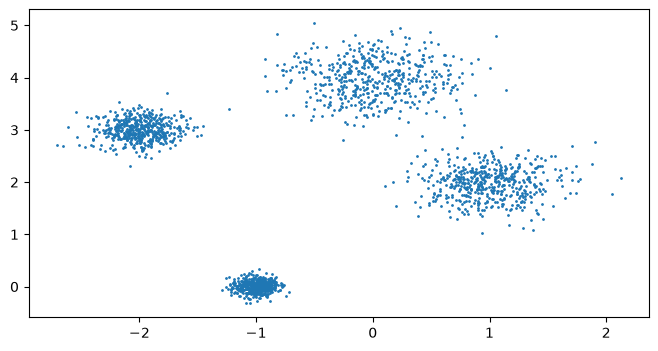

In [44]:
def plot_clusters(X,y=None):
    plt.scatter(X[:,0],X[:,1],c=y,s=1)
plt.figure(figsize=(8, 4))
plot_clusters(X)
plt.show()

In [45]:
kmeans.transform(X_new).round(2)

array([[ 1.98,  2.23,  0.99,  2.24],
       [ 5.37,  6.33,  4.01,  7.07],
       [ 9.5 , 10.63, 11.18,  8.06],
       [14.41, 10.63, 13.44, 12.53]])

In [48]:
from sklearn.metrics import silhouette_score
silhouette_score(X,kmeans.labels_)

0.7997869830548727

In [49]:
kmeans1 = KMeans(5,random_state=42)
y_pred1 = kmeans1.fit_predict(X)

In [50]:
silhouette_score(X,kmeans1.labels_)

0.7075302402146411

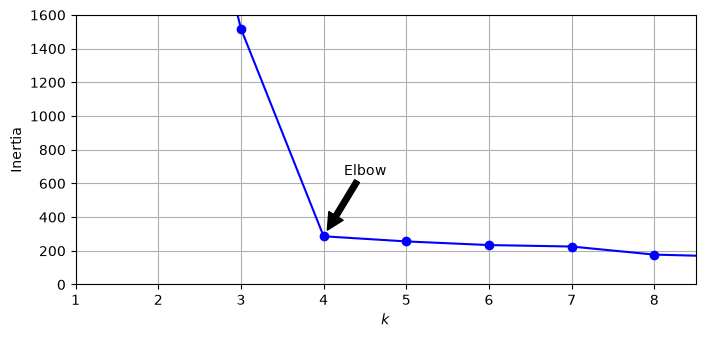

In [52]:
kmeans_per_k = [KMeans(n_clusters=k, random_state=43).fit(X)
                for k in range(1, 10)]
inertias = [model.inertia_ for model in kmeans_per_k]

plt.figure(figsize=(8, 3.5))
plt.plot(range(1, 10), inertias, "bo-")
plt.xlabel("$k$")
plt.ylabel("Inertia")
plt.annotate("", xy=(4, inertias[3]), xytext=(4.45, 650),
             arrowprops=dict(facecolor='black', shrink=0.1))
plt.text(4.5, 650, "Elbow", horizontalalignment="center")
plt.axis([1, 8.5, 0, 1600])
plt.grid()

plt.show()

In [54]:
#Image segmentation using k means
from pathlib import Path
import urllib.request

homlp_root = "https://github.com/ageron/handson-mlp/raw/main/"
filename = "ladybug.png"
filepath = Path(f"my_{filename}")
if not filepath.is_file():
    
    url = f"{homlp_root}/images/unsupervised_learning/{filename}"
    urllib.request.urlretrieve(url, filepath)

In [57]:
import PIL
img = np.array(PIL.Image.open(filepath))